# Logistic Regression Practice


## Imports <a class="anchor" id="imports"></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification, make_moons
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, auc, ConfusionMatrixDisplay

from Logistic_Regressor import LogisticRegressor

np.random.seed(0)

# 1D logistic regression

Data creation

In [2]:
X_1d, y_1d = make_classification(
    n_samples=200,
    n_features=1,
    n_informative=1,
    n_redundant=0,
    n_repeated=0,
    n_clusters_per_class=1,
    class_sep=1.5,
    random_state=0
)

Train/val/test split

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X_1d,
    y_1d,
    test_size=0.2,
    random_state=42,
    stratify=y_1d
)


X_train, X_val, y_train, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    stratify=y_train,
    random_state=123
)

print("Train shape:", X_train.shape)
print("Val shape:  ", X_val.shape)
print("Test shape: ", X_test.shape)


Train shape: (128, 1)
Val shape:   (32, 1)
Test shape:  (40, 1)


Plot the data

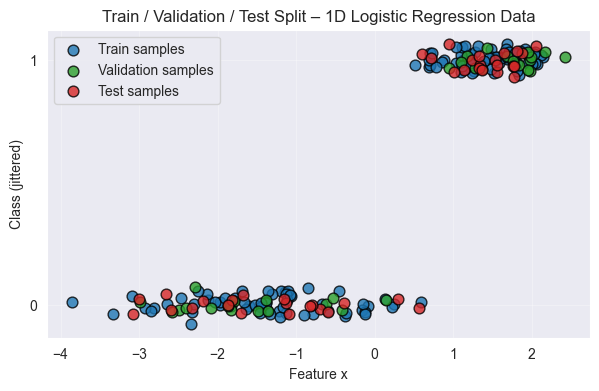

In [4]:
plt.figure(figsize=(7, 4))

# jitter for visibility
y_train_jitter = y_train + np.random.randn(*y_train.shape) * 0.03
y_val_jitter   = y_val   + np.random.randn(*y_val.shape)   * 0.03
y_test_jitter  = y_test  + np.random.randn(*y_test.shape)  * 0.03

# TRAIN (blue)
plt.scatter(
    X_train[:, 0],
    y_train_jitter,
    color="tab:blue",
    edgecolor="black",
    alpha=0.8,
    s=60,
    label="Train samples"
)

# VALIDATION (green)
plt.scatter(
    X_val[:, 0],
    y_val_jitter,
    color="tab:green",
    edgecolor="black",
    alpha=0.8,
    s=60,
    label="Validation samples"
)

# TEST (red)
plt.scatter(
    X_test[:, 0],
    y_test_jitter,
    color="tab:red",
    edgecolor="black",
    alpha=0.8,
    s=60,
    label="Test samples"
)

plt.title("Train / Validation / Test Split – 1D Logistic Regression Data")
plt.xlabel("Feature x")
plt.ylabel("Class (jittered)")
plt.yticks([0, 1])
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


Train GD-based logistic regression

In [5]:
gd_clf = LogisticRegressor()
gd_clf.fit(X_train, y_train, X_val=X_val, y_val=y_val)

print("GD weights:", gd_clf.weights_[0])
print("GD bias:", gd_clf.bias_)


GD weights: 4.910613219493644
GD bias: -1.6923342799494185


Evaluating the model (black box magic for now)

Training accuracy (GD): 0.9921875
Validation accuracy (GD): 1.0
Test accuracy (GD):      0.975


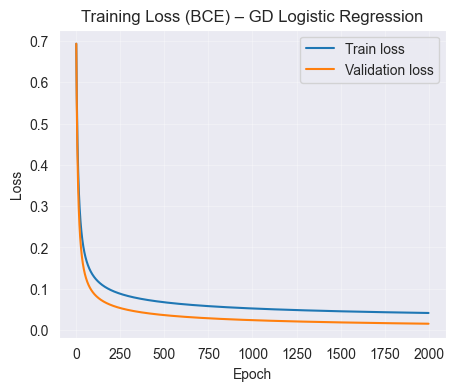

In [6]:
y_train_pred_gd = gd_clf.predict(X_train)
y_val_pred_gd   = gd_clf.predict(X_val)
y_test_pred_gd  = gd_clf.predict(X_test)

print("Training accuracy (GD):", accuracy_score(y_train, y_train_pred_gd))
print("Validation accuracy (GD):", accuracy_score(y_val, y_val_pred_gd))
print("Test accuracy (GD):     ", accuracy_score(y_test, y_test_pred_gd))

plt.figure(figsize=(5,4))
plt.plot(gd_clf.loss_history_, label="Train loss")
if gd_clf.val_loss_history_ is not None:
    plt.plot(gd_clf.val_loss_history_, label="Validation loss")
plt.title("Training Loss (BCE) – GD Logistic Regression")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


Train sklearn LogisticRegression for comparison

In [7]:
skl_clf = LogisticRegression()
skl_clf.fit(X_train, y_train)

print("sklearn coef_:", skl_clf.coef_)
print("sklearn intercept_:", skl_clf.intercept_)

y_train_pred_skl = skl_clf.predict(X_train)
y_val_pred_skl   = skl_clf.predict(X_val)
y_test_pred_skl  = skl_clf.predict(X_test)

print("Training accuracy (sklearn):", accuracy_score(y_train, y_train_pred_skl))
print("Validation accuracy (sklearn):", accuracy_score(y_val,   y_val_pred_skl))
print("Test accuracy (sklearn):     ", accuracy_score(y_test,  y_test_pred_skl))


sklearn coef_: [[3.23993234]]
sklearn intercept_: [-0.987107]
Training accuracy (sklearn): 0.9921875
Validation accuracy (sklearn): 1.0
Test accuracy (sklearn):      0.975


## Question for class: how can we get exact same score even thought we got different parameters?

Plot both sigmoids on 1D

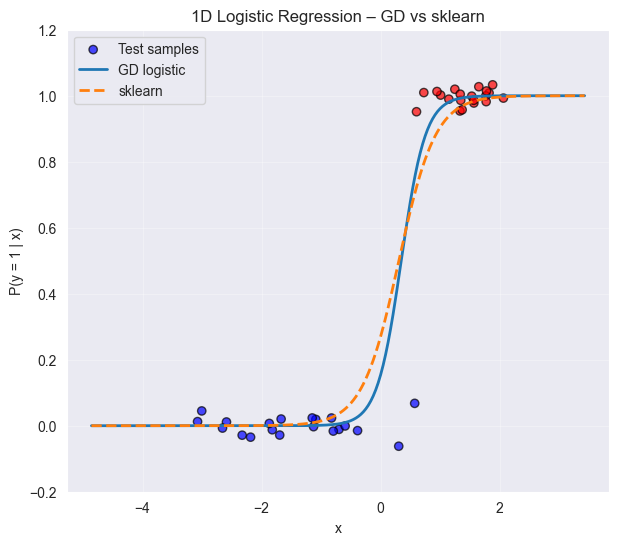

In [8]:
x_grid = np.linspace(X_1d.min() - 1, X_1d.max() + 1, 400).reshape(-1, 1)

p_grid_gd = gd_clf.predict_proba(x_grid)
p_grid_skl = skl_clf.predict_proba(x_grid)[:, 1]

plt.figure(figsize=(7, 6))

y_test_jitter = y_test + np.random.randn(*y_test.shape) * 0.03
plt.scatter(X_test[:, 0], y_test_jitter, c=y_test, cmap="bwr",
            edgecolor="black", alpha=0.7, label="Test samples")

plt.plot(x_grid[:, 0], p_grid_gd, label="GD logistic", linewidth=2)
plt.plot(x_grid[:, 0], p_grid_skl, "--", label="sklearn", linewidth=2)

plt.title("1D Logistic Regression – GD vs sklearn")
plt.xlabel("x")
plt.ylabel("P(y = 1 | x)")
plt.ylim(-0.2, 1.2)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


Confusion matrix on the TEST set

In [9]:
def print_confusion(y_true, y_pred, title="Confusion Matrix"):
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    print(title)
    print("              |  Predicted 0    | Predicted 1")
    print("-------------------------------------------------")
    print(f"Actual 0      |     {tn:3d}         |  {fp:3d}")
    print("-------------------------------------------------")
    print(f"Actual 1      |     {fn:3d}         |  {tp:3d}")
    print("\n")


print_confusion(y_test, y_test_pred_gd,  "GD Logistic – Test set")
print_confusion(y_test, y_test_pred_skl, "sklearn Logistic – Test set")


GD Logistic – Test set
              |  Predicted 0    | Predicted 1
-------------------------------------------------
Actual 0      |      19         |    1
-------------------------------------------------
Actual 1      |       0         |   20


sklearn Logistic – Test set
              |  Predicted 0    | Predicted 1
-------------------------------------------------
Actual 0      |      19         |    1
-------------------------------------------------
Actual 1      |       0         |   20




L2 regularization

In [10]:
# Note: the sklearn regressor uses by default the l2 regularization
from sklearn.linear_model import LogisticRegression

# "Almost no" regularization (large C)
clf_l2_weak = LogisticRegression(
    penalty="l2",
    C=100.0,           # large C -> weak regularization
    solver="lbfgs"
)
clf_l2_weak.fit(X_train, y_train)

# Strong regularization (small C)
clf_l2_strong = LogisticRegression(
    penalty="l2",
    C=0.1,            # small C -> strong regularization
    solver="lbfgs"
)
clf_l2_strong.fit(X_train, y_train)

print("=== L2 weak (C=100) ===")
print("w:", clf_l2_weak.coef_, " b:", clf_l2_weak.intercept_)
print("Train acc:", clf_l2_weak.score(X_train, y_train))
print("Test  acc:", clf_l2_weak.score(X_test, y_test))
print()

print("=== L2 strong (C=0.1) ===")
print("w:", clf_l2_strong.coef_, " b:", clf_l2_strong.intercept_)
print("Train acc:", clf_l2_strong.score(X_train, y_train))
print("Test  acc:", clf_l2_strong.score(X_test, y_test))


=== L2 weak (C=100) ===
w: [[10.67823821]]  b: [-5.08926118]
Train acc: 0.9921875
Test  acc: 0.975

=== L2 strong (C=0.1) ===
w: [[1.54734953]]  b: [-0.23860479]
Train acc: 0.9765625
Test  acc: 0.95


L1 and Elastic Net

In [11]:
# L1 (lasso-style) – needs 'liblinear' or 'saga'
clf_l1 = LogisticRegression(
    penalty="l1",
    C=0.1,
    solver="liblinear"
)
clf_l1.fit(X_train, y_train)

# Elastic Net (mix of L1 and L2) – needs 'saga'
clf_en = LogisticRegression(
    penalty="elasticnet",
    l1_ratio=0.5,     # 0 = pure L2, 1 = pure L1
    C=1.0,
    solver="saga",
    max_iter=5000
)
clf_en.fit(X_train, y_train)

print("=== L1 (C=0.1) ===")
print("w:", clf_l1.coef_, " b:", clf_l1.intercept_)
print("Train acc:", clf_l1.score(X_train, y_train))
print("Test  acc:", clf_l1.score(X_test, y_test))
print()

print("=== Elastic Net (l1_ratio=0.5, C=1.0) ===")
print("w:", clf_en.coef_, " b:", clf_en.intercept_)
print("Train acc:", clf_en.score(X_train, y_train))
print("Test  acc:", clf_en.score(X_test, y_test))


=== L1 (C=0.1) ===
w: [[1.85953891]]  b: [0.]
Train acc: 0.96875
Test  acc: 0.95

=== Elastic Net (l1_ratio=0.5, C=1.0) ===
w: [[3.70297739]]  b: [-1.22672297]
Train acc: 0.9921875
Test  acc: 0.975


Decision Boundary for 1D logistic regression

Decision boundary at x = 0.512


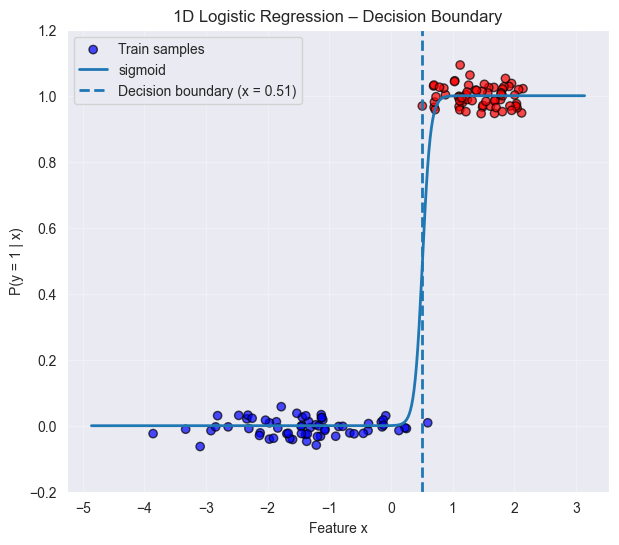

In [12]:
clf_none = LogisticRegression(
    penalty="l2",
    C=1e6,
    solver="lbfgs",
    max_iter=5000
)
clf_none.fit(X_train, y_train)   # ← MUST BE CALLED
model = clf_none   # <-- change this to the model you want

w = model.coef_[0, 0]
b = model.intercept_[0]

# x coordinate of the decision boundary: w * x + b = 0  ->  x = -b / w
x_decision = -b / w

print(f"Decision boundary at x = {x_decision:.3f}")

# grid to plot the sigmoid
x_grid = np.linspace(X_train.min() - 1, X_train.max() + 1, 400).reshape(-1, 1)
p_grid = model.predict_proba(x_grid)[:, 1]

plt.figure(figsize=(7, 6))

# training points with jitter in y so you see 0/1 separate
y_train_jitter = y_train + np.random.randn(*y_train.shape) * 0.03
plt.scatter(
    X_train[:, 0],
    y_train_jitter,
    c=y_train,
    cmap="bwr",
    edgecolor="black",
    alpha=0.7,
    label="Train samples"
)

# sigmoid curve
plt.plot(x_grid[:, 0], p_grid, linewidth=2, label="sigmoid")

# vertical decision boundary line
plt.axvline(
    x=x_decision,
    linestyle="--",
    linewidth=2,
    label=f"Decision boundary (x = {x_decision:.2f})"
)

plt.title("1D Logistic Regression – Decision Boundary")
plt.xlabel("Feature x")
plt.ylabel("P(y = 1 | x)")
plt.ylim(-0.2, 1.2)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


# 2D linear regression

2D data creation + train/test split

In [13]:
X_2d, y_2d = make_classification(
    n_samples=300,
    n_features=2,        # <<--- TWO features
    n_informative=2,
    n_redundant=0,
    n_repeated=0,
    n_clusters_per_class=1,
    class_sep=1.5,
    random_state=0
)

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X_2d,
    y_2d,
    test_size=0.3,
    random_state=42,
    stratify=y_2d
)

X2_train.shape, X2_test.shape


((210, 2), (90, 2))

Visualize 2D dataset

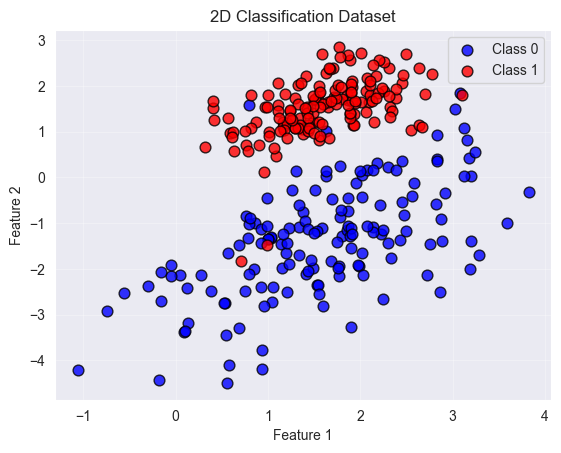

In [14]:
# class 0
plt.scatter(
    X_2d[y_2d == 0, 0],
    X_2d[y_2d == 0, 1],
    color="blue",
    edgecolor="black",
    alpha=0.8,
    s=60,
    label="Class 0"
)

# class 1
plt.scatter(
    X_2d[y_2d == 1, 0],
    X_2d[y_2d == 1, 1],
    color="red",
    edgecolor="black",
    alpha=0.8,
    s=60,
    label="Class 1"
)

plt.title("2D Classification Dataset")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


Train logistic regression (2D)

In [15]:
# use very weak L2 regularization (C large ≈ no reg)
clf_2d = LogisticRegression(
    penalty="l2",
    C=1e6,
    solver="lbfgs",
    max_iter=5000
)
clf_2d.fit(X2_train, y2_train)

print("=== 2D Logistic Regression (sklearn) ===")
print("coef_ (w):", clf_2d.coef_)      # shape (1, 2)
print("intercept (b):", clf_2d.intercept_)

y2_train_pred = clf_2d.predict(X2_train)
y2_test_pred  = clf_2d.predict(X2_test)

print("Train accuracy:", accuracy_score(y2_train, y2_train_pred))
print("Test  accuracy:", accuracy_score(y2_test,  y2_test_pred))


=== 2D Logistic Regression (sklearn) ===
coef_ (w): [[-2.39676929  3.50440883]]
intercept (b): [2.47074954]
Train accuracy: 0.9761904761904762
Test  accuracy: 0.9666666666666667


Visualize the decision boundary

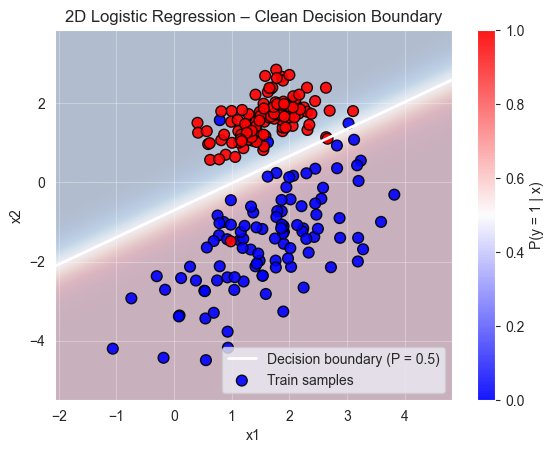

In [16]:
# Create a grid over the feature space
x_min, x_max = X_2d[:, 0].min() - 1, X_2d[:, 0].max() + 1
y_min, y_max = X_2d[:, 1].min() - 1, X_2d[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 400), np.linspace(y_min, y_max, 400))

grid_points = np.c_[xx.ravel(), yy.ravel()]
proba_grid = clf_2d.predict_proba(grid_points)[:, 1].reshape(xx.shape)
plt.imshow(proba_grid, origin="lower", extent=(x_min, x_max, y_min, y_max), cmap="RdBu", alpha=0.25,aspect="auto")
cs = plt.contour(xx, yy, proba_grid, levels=[0.5], colors="white", linewidths=2)
plt.plot([], [], color="white", linewidth=2, label="Decision boundary (P = 0.5)")

# ---------- training points ----------
plt.scatter(X2_train[:, 0], X2_train[:, 1], c=y2_train, cmap="bwr", edgecolor="black", s=60, alpha=0.9, label="Train samples")

plt.title("2D Logistic Regression – Clean Decision Boundary")
plt.xlabel("x1")
plt.ylabel("x2")
plt.legend()
plt.grid(True, alpha=0.3)

# colorbar for probabilities
cbar = plt.colorbar()
cbar.set_label("P(y = 1 | x)")

plt.show()


Confusion matrix for 2D logistic regression (test set)

In [17]:
print_confusion(y2_test, y2_test_pred, title="2D Logistic Regression – Test set")

2D Logistic Regression – Test set
              |  Predicted 0    | Predicted 1
-------------------------------------------------
Actual 0      |      44         |    1
-------------------------------------------------
Actual 1      |       2         |   43




## Non-linearly Separable Data <a class="anchor" id="nonlinear"></a>
Now we apply logistic regression to the **moons** dataset, where a linear classifier is not suitable.

create + visualize dataset

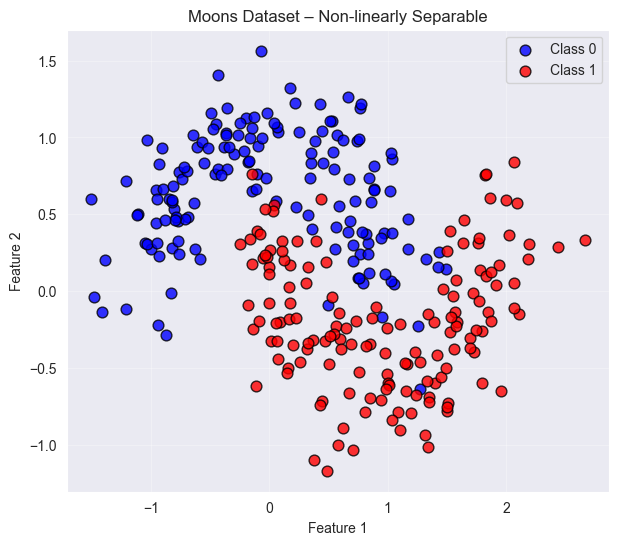

In [18]:
from sklearn.datasets import make_moons

# non-linearly separable 2D data
X_moon, y_moon = make_moons(
    n_samples=300,
    noise=0.25,
    random_state=0
)

X_m_train, X_m_test, y_m_train, y_m_test = train_test_split(
    X_moon,
    y_moon,
    test_size=0.3,
    random_state=42,
    stratify=y_moon
)

plt.figure(figsize=(7, 6))

plt.scatter(
    X_moon[y_moon == 0, 0],
    X_moon[y_moon == 0, 1],
    color="blue",
    edgecolor="black",
    s=60,
    alpha=0.8,
    label="Class 0"
)
plt.scatter(
    X_moon[y_moon == 1, 0],
    X_moon[y_moon == 1, 1],
    color="red",
    edgecolor="black",
    s=60,
    alpha=0.8,
    label="Class 1"
)

plt.title("Moons Dataset – Non-linearly Separable")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


Logistic regression on moons

In [19]:
clf_moon_linear = LogisticRegression(
    penalty="l2",
    C=1.0,
    solver="lbfgs",
    max_iter=5000
)
clf_moon_linear.fit(X_m_train, y_m_train)

y_m_train_pred_lin = clf_moon_linear.predict(X_m_train)
y_m_test_pred_lin  = clf_moon_linear.predict(X_m_test)

print("=== Linear logistic regression on moons ===")
print("coef_:", clf_moon_linear.coef_)
print("intercept_:", clf_moon_linear.intercept_)
print("Train accuracy:", accuracy_score(y_m_train, y_m_train_pred_lin))
print("Test  accuracy:", accuracy_score(y_m_test,  y_m_test_pred_lin))


=== Linear logistic regression on moons ===
coef_: [[ 1.09194531 -3.10657232]]
intercept_: [0.09079468]
Train accuracy: 0.8428571428571429
Test  accuracy: 0.8222222222222222


Decision boundary: linear logistic on moons

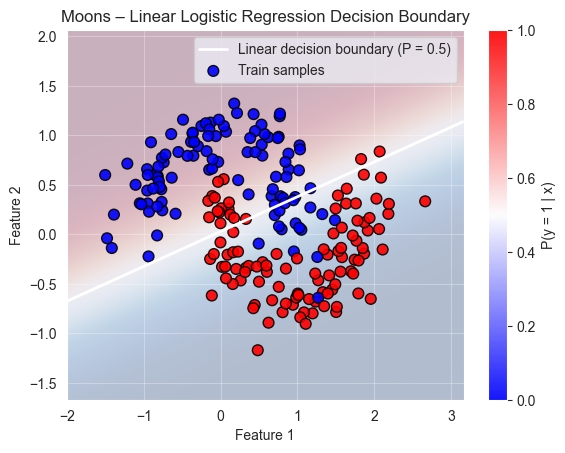

In [20]:
# grid over feature space
x_min, x_max = X_moon[:, 0].min() - 0.5, X_moon[:, 0].max() + 0.5
y_min, y_max = X_moon[:, 1].min() - 0.5, X_moon[:, 1].max() + 0.5

xx_m, yy_m = np.meshgrid(
    np.linspace(x_min, x_max, 400),
    np.linspace(y_min, y_max, 400)
)
grid_points_m = np.c_[xx_m.ravel(), yy_m.ravel()]
proba_grid_m = clf_moon_linear.predict_proba(grid_points_m)[:, 1].reshape(xx_m.shape)

# smooth background (no contour lines from levels)
plt.imshow(
    proba_grid_m,
    origin="lower",
    extent=(x_min, x_max, y_min, y_max),
    cmap="RdBu",
    alpha=0.25,
    aspect="auto"
)

# single linear decision boundary (P=0.5)
plt.contour(
    xx_m, yy_m, proba_grid_m,
    levels=[0.5],
    colors="white",
    linewidths=2
)
plt.plot([], [], color="white", linewidth=2, label="Linear decision boundary (P = 0.5)")

# training points
plt.scatter(
    X_m_train[:, 0],
    X_m_train[:, 1],
    c=y_m_train,
    cmap="bwr",
    edgecolor="black",
    s=60,
    alpha=0.9,
    label="Train samples"
)

plt.title("Moons – Linear Logistic Regression Decision Boundary")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.grid(True, alpha=0.3)
cbar = plt.colorbar()
cbar.set_label("P(y = 1 | x)")
plt.show()
